# Import necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from scipy import interpolate
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Introduction

## Dataset

In [ ]:
hawks_data = pd.read_csv('https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/Stat2Data/Hawks.csv')
hawks_data

,rownames,Month,Day,Year,CaptureTime,ReleaseTime,BandNumber,Species,Age,Sex,Wing,Weight,Culmen,Hallux,Tail,StandardTail,Tarsus,WingPitFat,KeelFat,Crop
0,1,9,19,1992,13:30,NaN,877-76317,RT,I,NaN,385.0,920.0,25.7,30.1,219,NaN,NaN,NaN,NaN,NaN
1,2,9,22,1992,10:30,,877-76318,RT,I,NaN,376.0,930.0,NaN,NaN,221,NaN,NaN,NaN,NaN,NaN
2,3,9,23,1992,12:45,,877-76319,RT,I,NaN,381.0,990.0,26.7,31.3,235,NaN,NaN,NaN,NaN,NaN
3,4,9,23,1992,10:50,,745-49508,CH,I,F,265.0,470.0,18.7,23.5,220,NaN,NaN,NaN,NaN,NaN
4,5,9,27,1992,11:15,,1253-98801,SS,I,F,205.0,170.0,12.5,14.3,157,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,904,11,18,2003,14:44,,1177-04777,RT,I,NaN,380.0,1525.0,26.0,27.6,224,227.0,NaN,NaN,3.0,0.0
904,905,11,19,2003,10:18,,803-05985,SS,I,F,190.0,175.0,12.7,15.4,150,153.0,NaN,NaN,4.0,0.0
905,906,11,19,2003,12:02,,1807-53145,RT,I,NaN,360.0,790.0,21.9,27.6,211,215.0,NaN,NaN,2.0,0.0
906,907,11,20,2003,9:56,,1177-04778,RT,I,NaN,369.0,860.0,25.2,28.0,207,210.0,NaN,NaN,2.0,0.0



<img src="https://storage.googleapis.com/kaggle-datasets-images/3867332/6710643/b91377eb21fdb7525657816a11f40952/dataset-cover.jpg" alt="drawing" width="900"/>


Students and faculty at Cornell College in Mount Vernon, Iowa, collected the data over many years at the hawk blind at Lake MacBride near Iowa City, Iowa. The data set that we are analyzing here is a subset of the original data set, using only those species for which there were more than 10 observations. Data were collected on random samples of three different species of hawks: Red-tailed, Sharp-shinned, and Cooper's hawks. The Dataset has 908 observations on the following 19 variables.



<table>
<tr>
<td style="text-align: right;">
<code>Month</code> </td><td style="text-align: left;"> code8=September to <code>12</code>=December</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Day</code> </td><td style="text-align: left;"> Date in the month</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Year</code> </td><td style="text-align: left;"> Year: 1992-2003</td>
</tr>
<tr>
<td style="text-align: right;">
<code>CaptureTime</code> </td><td style="text-align: left;"> Time of capture (HH:MM)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>ReleaseTime</code> </td><td style="text-align: left;"> Time of release (HH:MM)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>BandNumber</code> </td><td style="text-align: left;"> ID band code</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Species</code> </td><td style="text-align: left;"> <code>CH</code>=Cooper's, <code>RT</code>=Red-tailed,  <code>SS</code>=Sharp-Shinned</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Age</code> </td><td style="text-align: left;"> <code>A</code>=Adult or <code>I</code>=Imature</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Sex</code> </td><td style="text-align: left;"> <code>F</code>=Female or <code>M</code>=Male</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Wing</code> </td><td style="text-align: left;"> Length (in mm) of primary wing feather from tip to wrist it attaches to</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Weight</code> </td><td style="text-align: left;"> Body weight (in gm)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Culmen</code> </td><td style="text-align: left;"> Length (in mm) of the upper bill from the tip to where it bumps into the fleshy part of the bird</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Hallux</code> </td><td style="text-align: left;"> Length (in mm) of the killing talon</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Tail</code> </td><td style="text-align: left;"> Measurement (in mm) related to the length of the tail (invented at the MacBride Raptor Center)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>StandardTail</code> </td><td style="text-align: left;"> Standared measurement of tail length (in mm)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Tarsus</code> </td><td style="text-align: left;"> Length of the basic foot bone (in mm)</td>
</tr>
<tr>
<td style="text-align: right;">
<code>WingPitFat</code> </td><td style="text-align: left;"> Amount of fat in the wing pit</td>
</tr>
<tr>
<td style="text-align: right;">
<code>KeelFat</code> </td><td style="text-align: left;"> Amount of fat on the breastbone (measured by feel</td>
</tr>
<tr>
<td style="text-align: right;">
<code>Crop</code> </td><td style="text-align: left;"> Amount of material in the crop, coded from <code>1</code>=full to <code>0</code>=empty</td>
</tr>
<tr>
<td style="text-align: right;">
</td>
</tr>
</table>

### Coopers Hawk
<img src="https://www.meganstodel.com/posts/2020-05-23-ggplot2-hawks-1_files/coopers.jpg" alt="drawing" width="300"/>


### Red-Tailed Hawk
<img src="https://www.meganstodel.com/posts/2020-05-23-ggplot2-hawks-1_files/redtailed.jpg" alt="drawing" width="300"/>



### Sharp-shinned Hawk

<img src="https://www.meganstodel.com/posts/2020-05-23-ggplot2-hawks-1_files/sharpshinned.jpg" alt="drawing" width="300"/>


## Unsupervised Learning

Unsupervised learning in artificial intelligence is a type of machine learning that learns from data without human supervision. Unlike supervised learning, unsupervised machine learning models are given unlabeled data and allowed to discover patterns and insights without any explicit guidance or instruction.

In general, there are three types of unsupervised learning tasks: clustering, association rules, and dimensionality reduction.


<img src="https://images.datacamp.com/image/upload/v1661171231/Supervised_vs_Unsupervised_aa9a08ac32.png" alt="drawing" width="600"/>

### Clustering

Clustering is a technique for exploring raw, unlabeled data and breaking it down into groups (or clusters) based on similarities or differences. It is used in a variety of applications, including customer segmentation, fraud detection, and image analysis. Clustering algorithms split data into natural groups by finding similar structures or patterns in uncategorized data.

<img src="https://www.ejable.com/wp-content/uploads/2023/11/Unlabeled-data-vs.-labeled-clusters-2.webp" alt="drawing" width="600"/>

### Association Rules
Association rule mining is a rule-based approach to reveal interesting relationships between data points in large datasets. Unsupervised learning algorithms search for frequent if-then associations—also called rules—to discover correlations and co-occurrences within the data and the different connections between data objects.

It is most commonly used to analyze retail baskets or transactional datasets to represent how often certain items are purchased together.


<img src="
https://miro.medium.com/v2/resize:fit:770/1*meE1hYNAn0B9iV6DQznBXg.png" alt="drawing" width="600"/>

### Dimensionality reduction
Dimensionality reduction is an unsupervised learning technique that reduces the number of features, or dimensions, in a dataset. More data is generally better for machine learning, but it can also make it more challenging to visualize the data.

Dimensionality reduction extracts important features from the dataset, reducing the number of irrelevant or random features present. This method uses principle component analysis (PCA) and singular value decomposition (SVD) algorithms to reduce the number of data inputs without compromising the integrity of the properties in the original data.


<img src="
https://lh6.googleusercontent.com/proxy/5FoHrYaHli1iqNXZunq4wg9GrHhZJFfUlRYrBLpxOXLd1R7b9a8Hkk_uukWQbLTWlvmnq07l6yypWJXBZXDbdfbq5uOrc7e32I4AdrCezl4" alt="drawing" width="600"/>

## K-Means Clustering

K-means is often referred to as Lloyd’s algorithm. It is one of the most popular clustering algorithm. Refer below plot where there are two clusters (K=2) one is of red data points and another one of green data points.


<img src="
https://raw.githubusercontent.com/satishgunjal/images/master/Two_Cluster_Centroid_With_Datapoints.png" alt="drawing" width="600"/>

So how does K-Means algorithm find the clusters of the data points without any label?

* First step is to finalize the number of clusters you want to identify in your data. This is the "K" in K-means clustering.
* Now randomly initialize the points equal to the number of clusters K. 'Cluster Centroid' is the terminology used to refer these points. Note that centroid means center point of given dataset, but initially these points are at random location, but at the end when K-Means algorithm will converge they will be at the center of their respective cluster.
* Once cluster centroids are defined, K-means algorithm will go through each data point from given data and depending on that points closeness to cluster centroid, it will assign the data point to the cluster centroid. This is called as 'Assignment Step'.
* In order to move the cluster centroids from random location to their respective group, K-means algorithm will find the mean of each data point assigned to the cluster centroid and move the respective centroid to the mean value location. This is called as 'Move Centroid Step'
Note that during 'Move Centroid Step' data points can get reassigned from one cluster to another as centroid position change.
* Now repeat the assignment and move centroid steps till cluster centroid position don't change. K-means algorithm will converge when we get the unchanged position of cluster centroids.
Once K-means algorithm is converged, data point assigned to respective centroid will represent the respective cluster.



<img src="
https://raw.githubusercontent.com/satishgunjal/images/master/Inner_Working_K_Means.png" alt="drawing" width="300"/>


#### Random Initialization Trap

Since we have to randomly pick the cluster centroids, it's initialization may affect the final outcome of the clustering. In case our initialization is not correct, then K-Means algorithm may form a cluster with few points only. Such situation is referred as 'centroid random initialization trap' and it may cause algorithm to get stuck at local optima.

Check below plots, where for same dataset, we end up getting different clusters depending on initial position of cluster centroids. Gray color squares represent the initial positions of centroids and red, green and blue squares represent the final position of centroids.

<img src="
https://raw.githubusercontent.com/satishgunjal/images/master/Centroid_Random_Initialization_Trap.png" alt="drawing" width="300"/>

To avoid random initialization trap, follow below guidelines for random initialization.

* Number of cluster centroids should be less than number of training examples
* To avoid local optima issue, try to do multiple random initialization of centroids.
* Multiple random initialization technique is more effective when we have a small number of clusters.
* Similarly for large number of clusters, few random initialization are sufficient




### Selecting the number of Clusters or Value for K

Visualization ¶
To find the number of clusters manually by data visualization is one of the most common method. Domain knowledge and proper understanding of given data also help to make more informed decisions. Since it is a manual exercise there is always a scope for ambiguous observations, in such cases we can also use 'Elbow Method'

Elbow Method
In Elbow method we run the K-Means algorithm multiple times over a loop, with an increasing number of cluster choice(say from 1 to 10) and then plotting a clustering score as a function of the number of clusters. Clustering score is nothing but sum of squared distances of samples to their closest cluster center. Elbow is the point on the plot where clustering score (distortion) slows down, and the value of cluster at that point gives us the optimum number of clusters to have. But sometimes we don't get clear elbow point on the plot, in such cases its very hard to finalize the number of clusters.



<img src="
https://raw.githubusercontent.com/satishgunjal/images/master/K_Means_Elbow_Method.png" alt="drawing" width="600"/>

<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Simple, easy to understand and interpret</p>
</td>
<td>
<p class="p-margin">Number of clusters need to be defined by user (K=N you can Overfit)</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Since it uses simple computations it is relatively efficient</p>
</td>
<td>
<p class="p-margin">Doesn't work well in case of overlapping data or non circular clusters.</p>
</td>

</tr>
</tbody>
</table>

## Hierarchical clustering

Hierarchical clustering is a data analysis technique designed to sort data points into clusters, or groups, based on a set of similar characteristics. Hierarchical clustering works by creating a cluster “tree,” where clusters start larger and then break down into smaller groups at each branching point in the tree.

For example, you might be trying to categorize a group of animals. To do this, your top (largest) cluster might be the entire set of animals. Below this, your data might branch into smaller clusters by type of animal (mammal, reptile, and so on) and then further break down into clusters of species (mammals would break down into deer, dog, cat), and as you descend farther down your cluster tree. Hierarchical clustering is typically used for hierarchical data, meaning data that is easily subcategorized into different levels of specificity.

### Types of hierarchical clustering

You can choose your hierarchical clustering algorithm based on how you want your data split. The two main choices are divisive methods and agglomerative methods. Understanding each method can help you make a more informed decision about how best to structure the algorithm you’re using for your data.

1. **Agglomerative clustering**:
Agglomerative clustering is a “bottom-up” approach. First, every data point is categorized as an individual cluster. Following this, pairs of data points merge based on similarity. These pairs merge with other, most similar pairs, and so on, as clusters gradually combine up the “tree.” If you had a set of pictures, you could think of this as starting with each picture as its own “cluster.” Then, bit by bit, you would combine the pictures based on similarities until you have one big stack.

2. **Divisive clustering** :
This method is a “top-down” clustering approach. Essentially, it works oppositely compared to agglomerative clustering. Continuing with the photo analogy, you would start with one big pile of photos and gradually divide it into smaller piles based on differences until each photo is in a pile by itself or until the piles are distinct enough for your purpose

<img src="https://miro.medium.com/v2/resize:fit:1400/0*afzanWwrDq9vd2g-" alt="drawing" width="800"/>



<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Straightforward method for understanding data structure and relationships</p>
</td>
<td>
<p class="p-margin">Method relies heavily on the initial data allocation, and measurement errors can skew results</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">The hierarchy reveals natural groupings, meaning you don’t have to predefine the number of clusters</p>
</td>
<td>
<p class="p-margin">Introduces bias if the algorithm is not set up correctly for the type of data.</p>
</td>

</tr>
</tbody>
</table>

# Preperation/Cleaning and EDA

Lets remove some columns. Five features are retained: Year, Species, Weight, Wing, Tail and Hallux.

In [ ]:
hawks_data = hawks_data[['Year', 'Species', 'Weight', 'Wing', 'Tail','Hallux','Culmen']].copy()
hawks_data

,Year,Species,Weight,Wing,Tail,Hallux,Culmen
0,1992,RT,920.0,385.0,219,30.1,25.7
1,1992,RT,930.0,376.0,221,NaN,NaN
2,1992,RT,990.0,381.0,235,31.3,26.7
3,1992,CH,470.0,265.0,220,23.5,18.7
4,1992,SS,170.0,205.0,157,14.3,12.5
...,...,...,...,...,...,...,...
903,2003,RT,1525.0,380.0,224,27.6,26.0
904,2003,SS,175.0,190.0,150,15.4,12.7
905,2003,RT,790.0,360.0,211,27.6,21.9
906,2003,RT,860.0,369.0,207,28.0,25.2


Check for missing data

In [ ]:
hawks_data.isnull().values.any()

np.True_

Lets see what these rows look like

In [ ]:
hawks_data[hawks_data.isna().any(axis=1)]

,Year,Species,Weight,Wing,Tail,Hallux,Culmen
1,1992,RT,930.0,376.0,221,NaN,NaN
13,1992,RT,NaN,393.0,238,30.6,28.2
25,1992,SS,100.0,173.0,130,NaN,NaN
63,1993,RT,NaN,326.0,215,27.7,25.2
68,1993,SS,NaN,194.0,154,14.2,11.4
193,1994,RT,1040.0,403.0,229,29.9,NaN
217,1995,SS,NaN,202.0,164,NaN,NaN
262,1995,CH,480.0,NaN,198,32.1,17.7
314,1997,SS,NaN,162.0,130,NaN,NaN
331,1997,RT,1244.0,368.0,220,NaN,NaN


How many rows have missing data

In [ ]:
hawks_data.isnull().any(axis=1).sum()

np.int64(17)

Drop the missing data

In [ ]:
hawks_data=hawks_data.dropna()
hawks_data.isnull().values.any()

np.False_

Lets do some EDA

In [ ]:
# Show the frequency of different values in the column
hawks_data['Species'].value_counts()

,count
Species,
RT,567
SS,255
CH,69


Adding the parameter normalize=True shows the proportions.

In [ ]:
# Show the frequency of different values in the column as a proportion
hawks_data['Species'].value_counts(normalize=True).mul(100).round(1)

,proportion
Species,
RT,63.6
SS,28.6
CH,7.7


Exploring the numeric features:
To begin you could look for a numeric feature that has a higher or lower average for one species compared to the others.

The following code makes a list of the numeric features and shows the average grouped by Species.

In [ ]:
# Make a list of numeric features
numeric_features = ['Wing', 'Weight', 'Tail', 'Hallux','Culmen']
# Show how the averages differ based on species
hawks_data.groupby('Species')[numeric_features].mean().round(2)

,Wing,Weight,Tail,Hallux,Culmen
Species,,,,,
CH,244.14,419.62,200.96,22.68,17.56
RT,383.63,1094.84,222.13,32.01,26.97
SS,184.88,148.16,146.68,14.97,11.47


The Wing of Red-tailed Hawks seems to be higher than the others.

To explore Wing further you could use the describe function.

In [ ]:
# Show how Wing differs between species
hawks_data.groupby('Species')['Wing'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
CH,69.0,244.14,32.13,145.0,227.0,240.0,260.0,377.0
RT,567.0,383.63,31.26,37.2,372.0,384.0,399.0,480.0
SS,255.0,184.88,22.56,143.0,165.5,191.0,199.0,370.0


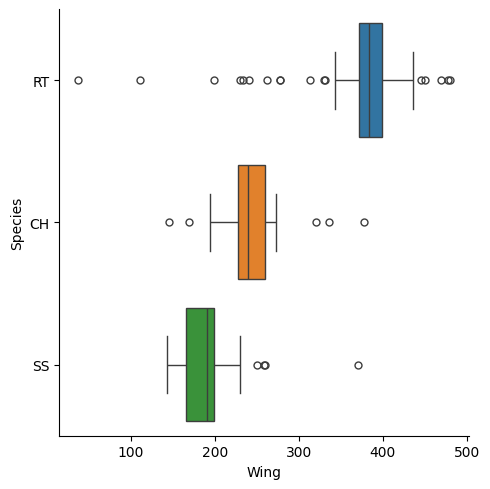

In [ ]:
# Show a plot of Wing broken down by Species
sns.catplot(data=hawks_data, kind='box', x='Wing', y='Species', hue='Species')

Lets look at Tails

In [ ]:
# Show how Tail differs between species
hawks_data.groupby('Species')['Tail'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
CH,69.0,200.96,18.01,157.0,186.0,200.0,215.0,233.0
RT,567.0,222.13,14.60,122.0,214.0,221.0,230.0,288.0
SS,255.0,146.68,15.72,119.0,133.0,150.0,157.5,221.0


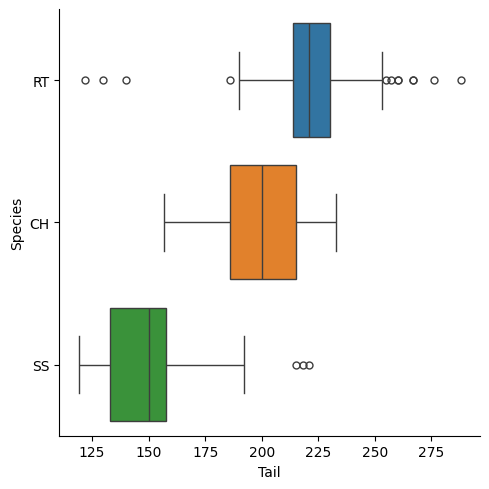

In [ ]:
# Show a plot of Tail broken down by Species
sns.catplot(data=hawks_data, kind='box', x='Tail', y='Species', hue='Species')

To view for each pair of variable. We can plot the pair plots

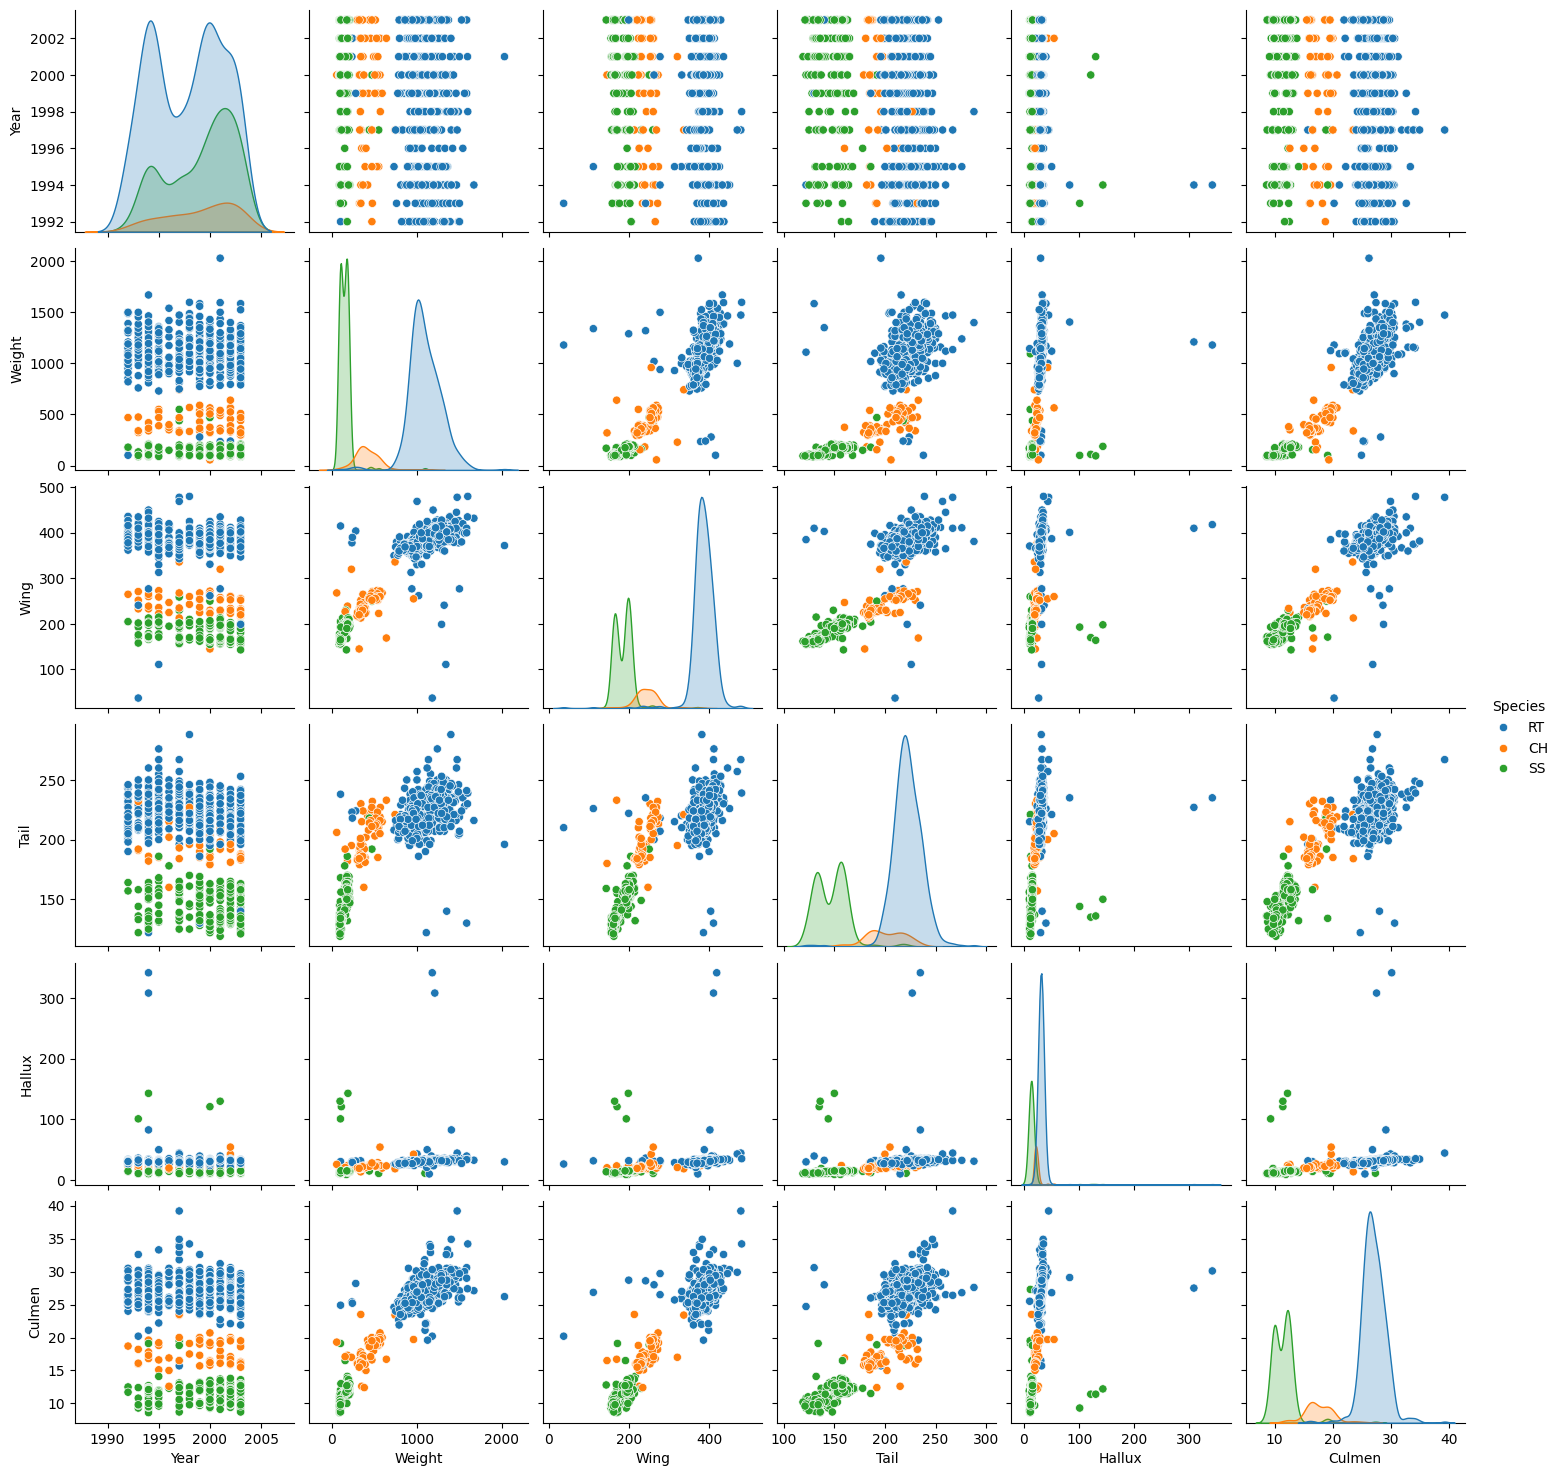

In [ ]:
_ = sns.pairplot(data=hawks_data,hue='Species')

# Clustering with K-Means

The k-means algorithm searches for a pre-determined number of clusters within an unlabeled multidimensional dataset. It accomplishes this using a simple conception of what the optimal clustering looks like:

* The "cluster center" is the arithmetic mean of all the points belonging to the cluster.
* Each point is closer to its own cluster center than to other cluster centers.

Those two assumptions are the basis of the k-means model

###k-Means Algorithm: Expectation–Maximization

Expectation–maximization (E–M) is a powerful algorithm that comes up in a variety of contexts within data science. k-means is a particularly simple and easy-to-understand application of the algorithm, and we will walk through it briefly here. In short, the expectation–maximization approach here consists of the following procedure:

1. Guess some cluster centers
2. Repeat until converged
    1. E-Step: assign points to the nearest cluster center
    2. M-Step: set the cluster centers to the mean

Here the "E-step" or "Expectation step" is so-named because it involves updating our expectation of which cluster each point belongs to. The "M-step" or "Maximization step" is so-named because it involves maximizing some fitness function that defines the location of the cluster centers—in this case, that maximization is accomplished by taking a simple mean of the data in each cluster.


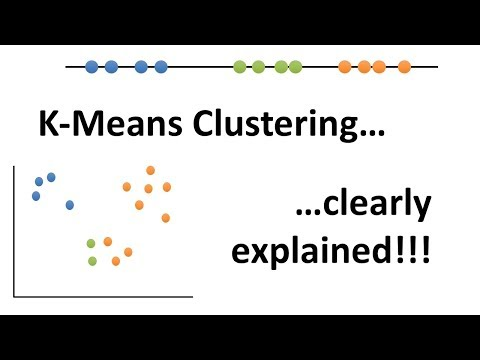

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo("4b5d3muPQmA",560,315,rel=0)

We will attempt to cluster the species given the 5 features

In [ ]:
cluster_data = hawks_data[["Wing", "Weight", "Tail", "Culmen", "Hallux"]].copy()
cluster_data

,Wing,Weight,Tail,Culmen,Hallux
0,385.0,920.0,219,25.7,30.1
2,381.0,990.0,235,26.7,31.3
3,265.0,470.0,220,18.7,23.5
4,205.0,170.0,157,12.5,14.3
5,412.0,1090.0,230,28.5,32.2
...,...,...,...,...,...
903,380.0,1525.0,224,26.0,27.6
904,190.0,175.0,150,12.7,15.4
905,360.0,790.0,211,21.9,27.6
906,369.0,860.0,207,25.2,28.0


Lets start by Scaling the data. Since K-Means is a distance based algorithm this is very important

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler to the data
scaler.fit(cluster_data)

# Transform the data
X = scaler.transform(cluster_data)
X

array([[0.78545619, 0.43768997, 0.59171598, 0.55882353, 0.06206689],
       [0.77642276, 0.47315096, 0.68639053, 0.59150327, 0.06568243],
       [0.51445348, 0.20972644, 0.59763314, 0.33006536, 0.04218138],
       ...,
       [0.72899729, 0.37183384, 0.5443787 , 0.43464052, 0.0545345 ],
       [0.74932249, 0.40729483, 0.52071006, 0.54248366, 0.05573968],
       [0.36540199, 0.62512665, 0.60946746, 0.65686275, 0.0680928 ]])

Elbow method

Text(0.5, 0, 'cluster')

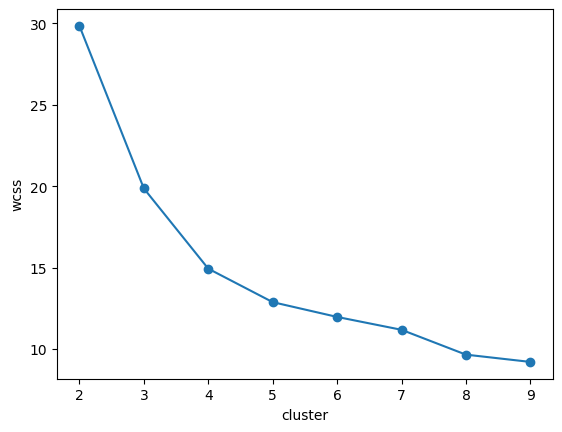

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init='auto',random_state = 46)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # within-cluster sum of squares
plt.plot(np.arange(2, 10), wcss, marker='o')
plt.ylabel('wcss')
plt.xlabel('cluster')

Both 3 and 4 Look Plausible.

Fitting the data with the K-Means Model (K=3) and visualize using just 2 Features

<Axes: xlabel='Wing', ylabel='Tail'>

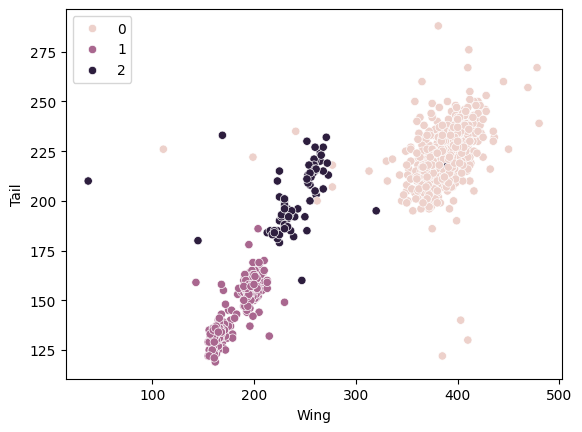

In [ ]:
kmeans = KMeans(n_clusters=3,n_init="auto",random_state=46)
kmeans.fit(X)
y_kmeans_3 = kmeans.predict(X)

sns.scatterplot(x=cluster_data['Wing'], y=cluster_data['Tail'], hue=y_kmeans_3)


Text(0.5, 1.0, '5D Cluster using 2D')

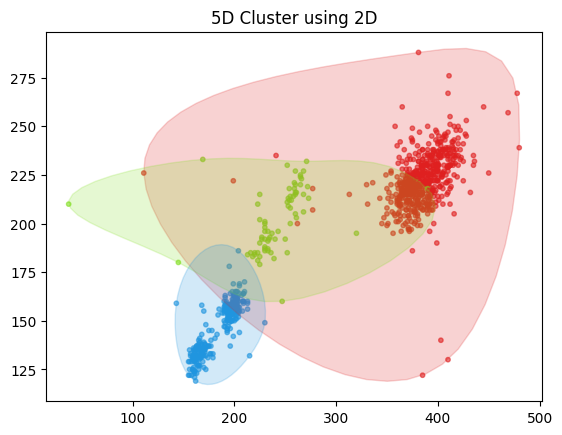

In [ ]:
df=cluster_data.copy()
df['cluster']=y_kmeans_3
# define and map colors
colors = ['#DF2020', '#2095DF', '#81DF20']
df['c'] = df.cluster.map({0:colors[0], 1:colors[1], 2:colors[2]})

plt.scatter(df.Wing, df.Tail, c=df.c, alpha = 0.6, s=10)

for i in df.cluster.unique():
    # get the convex hull
    points = df[df.cluster == i][['Wing', 'Tail']].values
    hull = ConvexHull(points)
    x_hull = np.append(points[hull.vertices,0],
                       points[hull.vertices,0][0])
    y_hull = np.append(points[hull.vertices,1],
                       points[hull.vertices,1][0])

    # interpolate
    dist = np.sqrt((x_hull[:-1] - x_hull[1:])**2 + (y_hull[:-1] - y_hull[1:])**2)
    dist_along = np.concatenate(([0], dist.cumsum()))
    spline, u = interpolate.splprep([x_hull, y_hull],
                                    u=dist_along, s=0, per=1)
    interp_d = np.linspace(dist_along[0], dist_along[-1], 50)
    interp_x, interp_y = interpolate.splev(interp_d, spline)
    # plot shape
    plt.fill(interp_x, interp_y, '--', c=colors[i], alpha=0.2)

plt.title('5D Cluster using 2D')




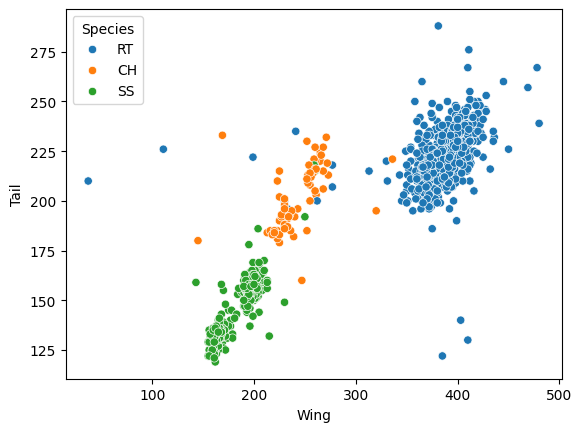

In [ ]:
_ = sns.scatterplot(data=cluster_data, x='Wing', y='Tail', hue=hawks_data['Species'])

With 3 Features

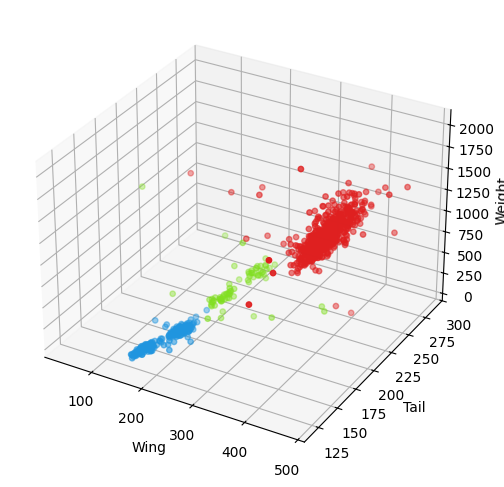

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(26,6))
ax = fig.add_subplot(131, projection='3d')
ax.scatter(df.Wing, df.Tail, df.Weight, c=df.c, s=15)
ax.set_xlabel('Wing')
ax.set_ylabel('Tail')
ax.set_zlabel('Weight')
plt.show()

# K-Means on Synthetic Data

##Stepwise working of KMeans on Synthetic Data

For a more detailed visual playground of Kmeans [Click Here](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

iterations starting


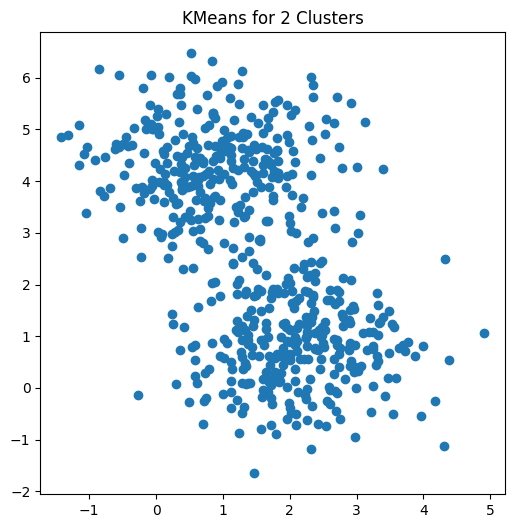

Chosen Random Centroids :

[[[ 1.96373997  0.91501511]
  [-0.07236478  5.11453117]]]


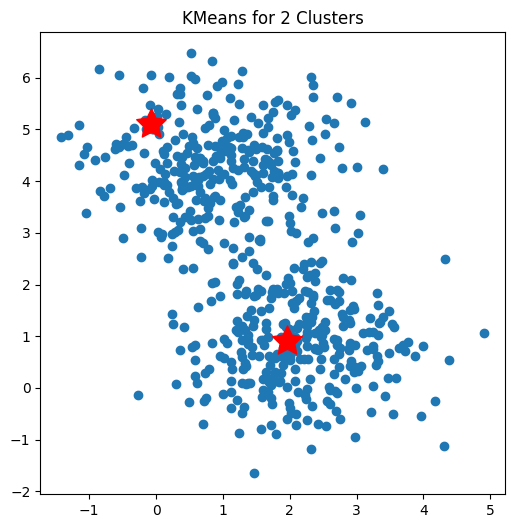

iter: 1 - first: [2.10512715 0.84000617], second: [0.89507277 4.30414216]


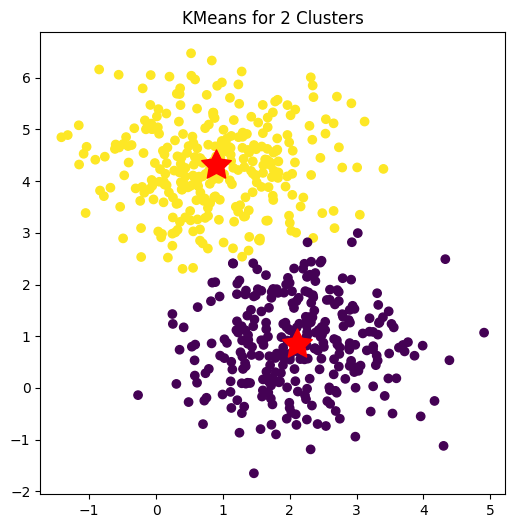

iter: 2 - first: [2.11952699 0.84394718], second: [0.88057662 4.30017479]


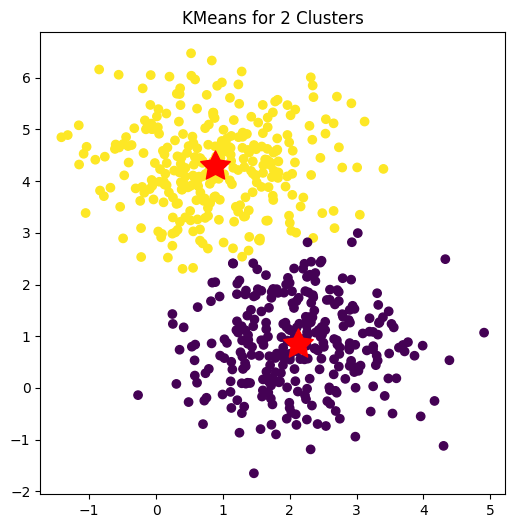

iter: 3 - first: [2.11952699 0.84394718], second: [0.88057662 4.30017479]


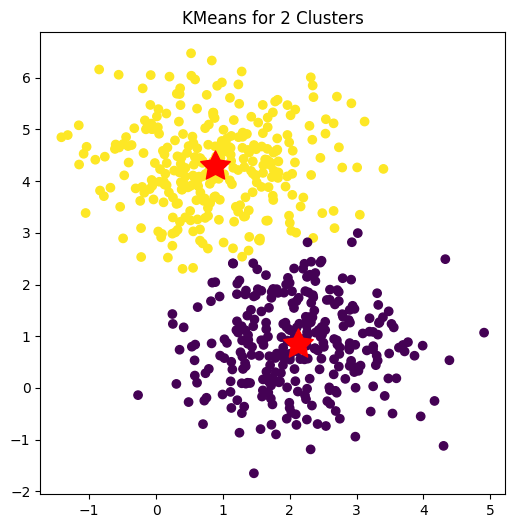

iter: 4 - first: [2.11952699 0.84394718], second: [0.88057662 4.30017479]


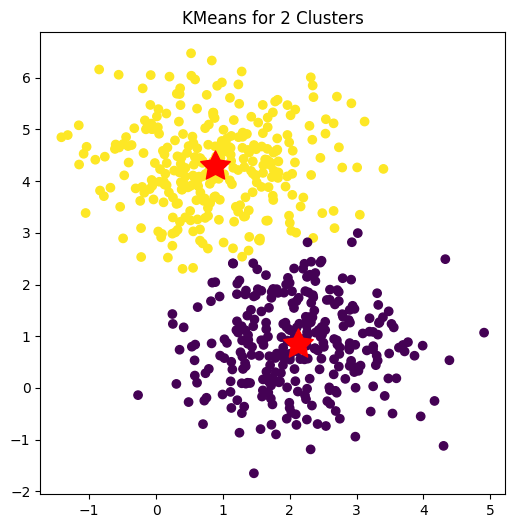

In [ ]:
from sklearn.datasets import make_blobs

X,_= make_blobs(n_samples=600, centers=2,
                       cluster_std=0.90, random_state=0)
iterations = 4
indx=np.random.randint(600, size=(1,2))
print(f'iterations starting')
plt.figure(figsize=(6, 6))
plt.scatter(X[:,0],X[:,1])
plt.title("KMeans for 2 Clusters")
plt.savefig('0.jpg')
plt.show()
print("Chosen Random Centroids :\n")
ran_val=X[indx,:]
print(ran_val)
centroids = [[ran_val[0][0][0],ran_val[0][1][0]],[ran_val[0][0][1],ran_val[0][1][1]]]
plt.figure(figsize=(6, 6))
plt.scatter(X[:,0],X[:,1])
plt.scatter(centroids[0],centroids[1], s=500,marker=(5, 1),c='red')
plt.title("KMeans for 2 Clusters")
plt.savefig('1.jpg')
plt.show()
row=col=0
for i in range(iterations):
    plt.figure(figsize=(6, 6))
    kmeans = KMeans(
        max_iter=1,
        n_init=1,
        init=(centroids),
        n_clusters=2,
        random_state=1)
    kmeans.fit(X)
    centroids = kmeans.cluster_centers_
    print(f'iter: {i+1} - first: {centroids[0]}, second: {centroids[1]}')
    plt.scatter(X[:,0],X[:,1],c=kmeans.labels_)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=500,marker=(5, 1),c='red')
    plt.title("KMeans for 2 Clusters")
    plt.savefig(str(i+2)+'.jpg')
    plt.show()
    col=col+1
    if col==2:
        col=0
        row=row+1

GIF Stored in :  /content


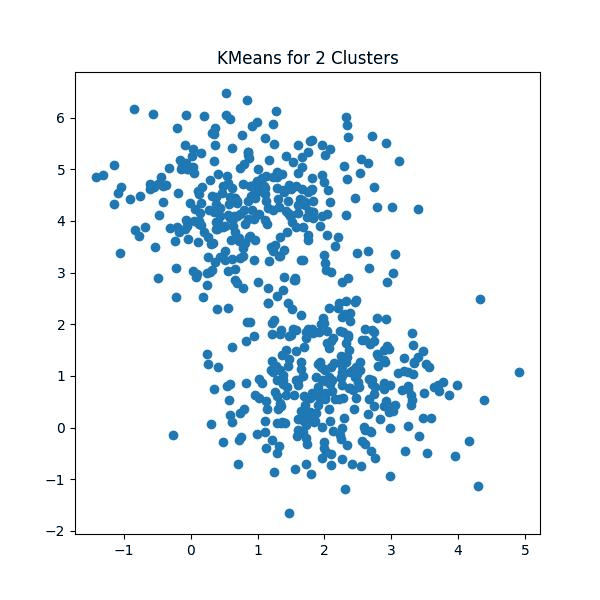

In [ ]:
import glob
import os
cwd=os.getcwd()
print("GIF Stored in : ",cwd)
def make_gif(frame_folder):
    from PIL import Image
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.jpg"))]
    frame_one = frames[0]
    frame_one.save("kmean_ani.gif", format="GIF", append_images=frames,save_all=True, duration=2000, loop=0)
make_gif(str(cwd)+"/")
from IPython.display import Image
Image(str(cwd)+"/kmean_ani.gif")

Generate another artificial Dataset

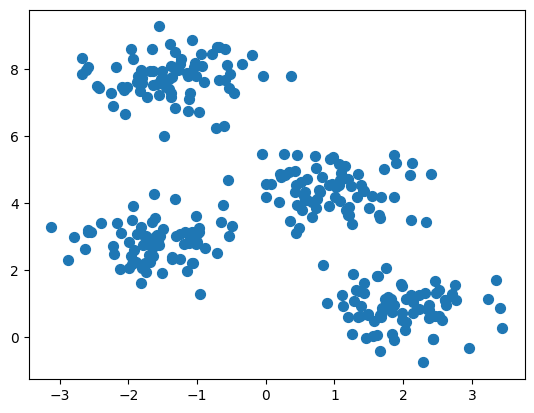

In [ ]:
X_a, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X_a[:, 0], X_a[:, 1], s=50);

Compute K-means and Visualize

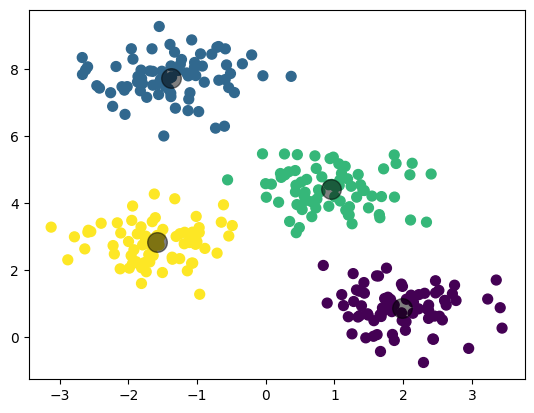

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4,n_init="auto")
kmeans.fit(X_a)
y_kmeans = kmeans.predict(X_a)

plt.scatter(X_a[:, 0], X_a[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

# Principal Components Analysis

Principal component analysis, or PCA, is a dimensionality reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information in the large set.

Reducing the number of variables of a data set naturally comes at the expense of accuracy, but the trick in dimensionality reduction is to trade a little accuracy for simplicity. Because smaller data sets are easier to explore and visualize, and thus make analyzing data points much easier and faster for machine learning algorithms without extraneous variables to process.

So, to sum up, the idea of PCA is simple: **reduce the number of variables/features of a data set, while preserving as much information as possible.**

[Click here](https://projector.tensorflow.org/) for a nice PCA Playground of Word embeddings

## What Are Principal Components?

Principal components are new variables that are constructed as linear combinations or mixtures of the initial variables. These combinations are done in such a way that the new variables (i.e., principal components) are uncorrelated and most of the information within the initial variables is squeezed or compressed into the first components. So, the idea is 10-dimensional data gives you 10 principal components, but PCA tries to put maximum possible information in the first component, then maximum remaining information in the second and so on, until having something like shown in the scree plot below

<img src="http://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/national/Principal%2520Component%2520Analysis%2520Principal%2520Components.png" alt="drawing" width="500"/>

Organizing information in principal components this way will allow you to reduce dimensionality without losing much information, and this by discarding the components with low information and considering the remaining components as your new variables.

An important thing to realize here is that the principal components are less interpretable and don’t have any real meaning since they are constructed as linear combinations of the initial variables.

Geometrically speaking, principal components represent the directions of the data that explain a **maximal amount of variance**, that is to say, the lines that capture most information of the data.The relationship between variance and information here, is that, the larger the variance carried by a line, the larger the dispersion of the data points along it, and the larger the dispersion along a line, the more information it has.

## How PCA Constructs the Principal Components


As there are as many principal components as there are variables in the data, principal components are constructed in such a manner that the first principal component accounts for the largest possible variance in the data set. For example, let’s assume that the scatter plot of our data set is as shown below, can we guess the first principal component ? Yes, it’s approximately the line that matches the purple marks because it goes through the origin and it’s the line in which the projection of the points (red dots) is the most spread out. Or mathematically speaking, it’s the line that maximizes the variance (the average of the squared distances from the projected points (red dots) to the origin).


The second principal component is calculated in the same way, with the condition that it is uncorrelated with (i.e., perpendicular to) the first principal component and that it accounts for the next highest variance.

This continues until a total of p principal components have been calculated, equal to the original number of variables.




<img src="https://miro.medium.com/v2/resize:fit:1400/0*TXIbCytfgo5p5hty.gif" alt="drawing" width="900"/>

Additionally, one can imagine that the black line is a solid rod and each red line is a spring. The energy of the spring is proportional to its squared length (this is known in physics as the Hooke's law), so the rod will orient itself such as to minimize the sum of these squared distances.



<img src="https://bradleyboehmke.github.io/HOML/15-pca_files/figure-html/create-pca-image-1.png" alt="drawing" width="500"/>




<img src="https://www.researchgate.net/publication/363426936/figure/fig2/AS:11431281083760364@1662773131653/Reduce-data-dimensions-using-the-basic-component-analysis-method.png" alt="drawing" width="800"/>

<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">PCA is effective in reducing the dimensionality of large datasets, which can significantly improve the performance of machine learning algorithms </p>
</td>
<td>
<p class="p-margin"> PCA involves transforming original features into principal components, which can lead to a loss of interpretability</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">PCA can help reduce noise in the data by retaining only the principal components that explain the most variance.</p>
</td>
<td>
<p class="p-margin">PCA is sensitive to outliers, which can distort the principal components and affect the accuracy of the results. Scaling data before applying PCA can help mitigate some issues</p>
</td>
</tr>
</tbody>
</table>

Lets fit PCA to out 5 Features and Plot a Scree Plot

In [ ]:
PCA_TR = PCA(n_components=5,random_state=46)
X = scaler.transform(cluster_data)
X_train = PCA_TR.fit_transform(X)

In [ ]:
PCA_TR.explained_variance_ratio_

array([0.93312849, 0.03194304, 0.01482048, 0.0110985 , 0.00900949])

In [ ]:
0.93312849 + 0.03194304

0.96507153

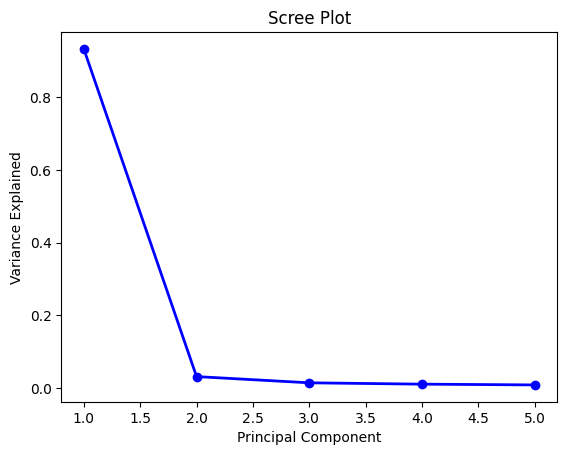

In [ ]:
PC_values = np.arange(PCA_TR.n_components_) + 1
plt.plot(PC_values, PCA_TR.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

Looks like just the first 2 Components has about 96% Explained Variance (as seen above). and 2 Dimensions is also easy to visualize

In [ ]:
#Refit the model to give us only 2 Components
PCA_TR = PCA(n_components=2,random_state=46)
X_train = PCA_TR.fit_transform(X)

In [ ]:
PCA_TR.explained_variance_ratio_

array([0.93312849, 0.03194304])

What is each Feature's contribution in principal components

It is important to realize that the principal components are less interpretable and don't have any real meaning since they are constructed as linear combinations of the initial variables. But we can analyze the loadings which describe the importance of the independent variables. The loadings are from a numerical point of view, equal to the coefficients of the variables, and provide information about which variables give the largest contribution to the components.

Loadings range from -1 to 1.
A high absolute value (towards 1 or -1) describes that the variable strongly influences the component. Values close to 0 indicate that the variable has a weak influence on the component.
The sign of a loading (+ or -) indicates whether a variable and a principal component are positively or negatively correlated.

In [ ]:
pd.DataFrame(PCA_TR.components_,columns=["Wing", "Weight", "Tail", "Culmen", "Hallux"],index = ['PC-1','PC-2'])

,Wing,Weight,Tail,Culmen,Hallux
PC-1,0.476429,0.516599,0.467663,0.533341,0.054577
PC-2,-0.128890,-0.505734,0.842556,-0.132541,-0.012348


Using PC-1 and PC-2 as new Features lets plot the scatter plot

<Axes: >

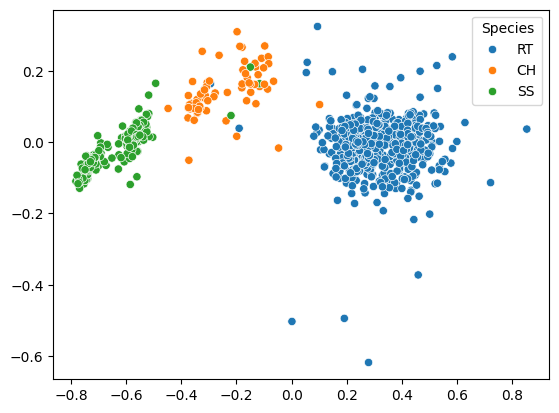

In [ ]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=hawks_data['Species'])

Running K-Means using the new features and ploting the corresponding clusters

<Axes: >

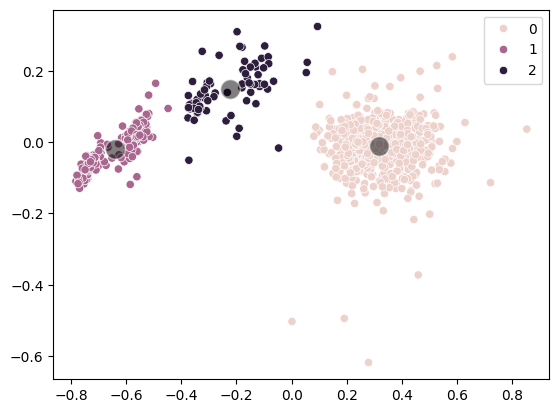

In [ ]:
kmeans = KMeans(n_clusters=3,n_init="auto",random_state=46)
kmeans.fit(X_train)
y_kmeans = kmeans.predict(X_train)

sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_kmeans)
centers = kmeans.cluster_centers_

sns.scatterplot(x=centers[:, 0], y=centers[:, 1],c='black', s=200, alpha=0.5)

You can also use these transformed features as inputs to supervised learning.
Here we use a K-Nearest Neighbour algorithm to predict the Species

Accuracy is 0.9865319865319865


<Axes: >

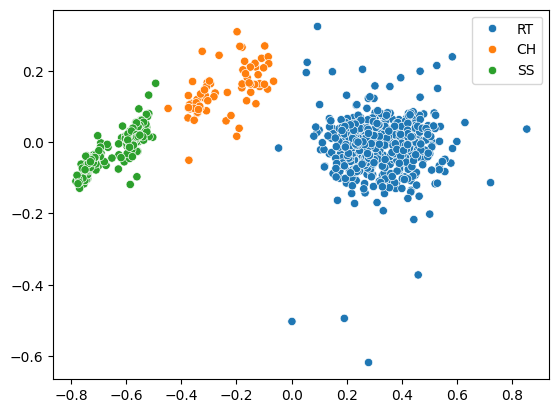

In [ ]:
# KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)


#fiting to training data
classifier.fit(X_train, hawks_data['Species'])

y_pred = classifier.predict(X_train)

# Accuracy score
from sklearn.metrics import accuracy_score
print('Accuracy is',accuracy_score(y_pred,hawks_data['Species']))

sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_pred)

##Case Study : EigenFaces

Eigenfaces leverage Principal Component Analysis (PCA) to reduce the dimensionality of face image datasets (Labelled Faces in the Wild), enabling efficient and robust facial recognition by representing faces as linear combinations of a smaller set of basis images (eigenfaces).

4324 samples: The dataset contains 4324 face images.

2914 features per sample: Each face image is represented as a flattened vector of 2914 pixel values (original image resolution is 62x47 pixels).

Dimensions of the data: (4324, 2914)
Dimensions with 90% - 95% explained variance after PCA: 104  -  207
Dimensions after PCA: (4324, 156)


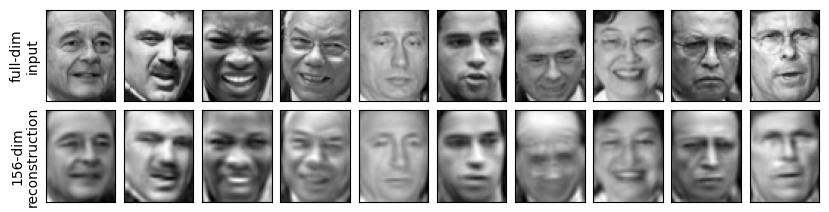

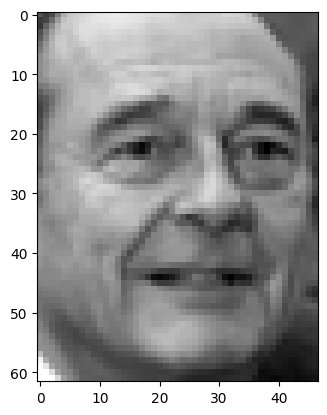

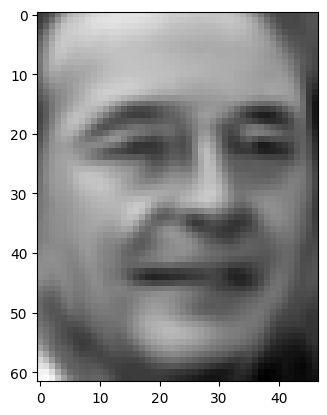

In [ ]:
from sklearn.datasets import fetch_lfw_people

#Loading the data
faces = fetch_lfw_people(min_faces_per_person=10)
print("Dimensions of the data:", faces.data.shape)

pca = PCA(n_components=0.90).fit(faces.data) #Use can use PCA and specify how much explained variance you want - it will select the required components
components_90 = pca.transform(faces.data)
pca = PCA(n_components=0.95).fit(faces.data)
components_95 = pca.transform(faces.data)
print("Dimensions with 90% - 95% explained variance after PCA:", components_90.shape[1]," - ",components_95.shape[1])


# Compute the components and projected faces usig 156 as sweet spot of 90% - 95% explained variance
pca = PCA(156, svd_solver='randomized').fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)
print("Dimensions after PCA:", components.shape)


# Plot the results
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('156-dim\nreconstruction');
plt.show()

plt.imshow(faces.data[0].reshape(62, 47), cmap='binary_r')
plt.imsave('original.png', faces.data[0].reshape(62, 47), cmap='binary_r')
plt.show()

plt.imshow(projected[0].reshape(62, 47), cmap='binary_r')
plt.imsave('reconstructed.png', faces.data[0].reshape(62, 47), cmap='binary_r')
plt.show()

# Agglommerative Clustering

Agglomerative Clustering is a type of hierarchical clustering technique used to build clusters from bottom up. Divisive Clustering is the opposite method of building clusters from top down, which is not available in sklearn.

The most useful part of such a clustering is the ability to draw a dendrogram to view the breakdown of clusters with a increasing distance.


<img src="https://github.com/mapattacker/datascience/blob/master/images/aggocluster.png?raw=true" alt="drawing" width="900"/>

How do we link to form clusters, methods of linking clusters (ward, average, complete)




<img src="https://github.com/mapattacker/datascience/blob/master/images/aggocluster2.png?raw=true" alt="drawing" width="900"/>

In [ ]:
def plot_dendrogram(model, **kwargs):
    from scipy.cluster.hierarchy import dendrogram

    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


In [ ]:
# Load the Iris dataset
iris = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
#For EDA of Iris dataset see the Classification Notebook

# Create a numpy array of the features
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# setting distance_threshold=0 ensures we compute the full tree.
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

In [ ]:
"""
clustering = AgglomerativeClustering(n_clusters=3, # chose 3 since we know the iris dataset has three different species
                             metric='euclidean',compute_distances=True,
                             linkage='complete')
"""

"\nclustering = AgglomerativeClustering(n_clusters=3, # chose 3 since we know the iris dataset has three different species\n                             metric='euclidean',compute_distances=True,\n                             linkage='complete')\n"

In [ ]:
clustering = AgglomerativeClustering(n_clusters=3, # chose 3 since we know the iris dataset has three different species
                             metric='euclidean',compute_distances=True,
                             linkage='complete')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler to the data
scaler.fit(X)

# Transform the data
X_t = scaler.transform(X)

In [ ]:
# Fit the model to the data
model=clustering.fit(X_t)

In [ ]:
labels = clustering.fit_predict(X_t)
print(f'Cluster labels: {labels}')

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 0 0 0 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 0 0 0 2 0 2 2 0 2 2 2 0 0 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


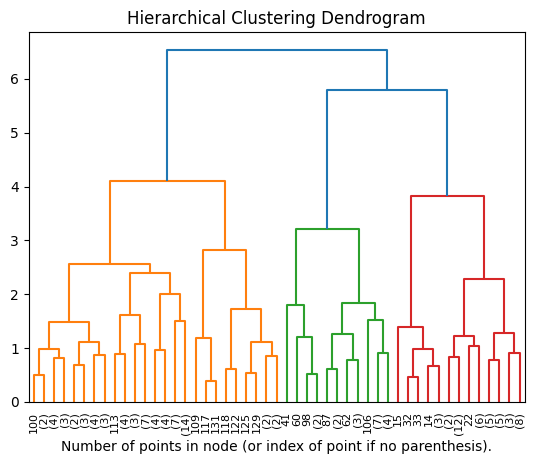

In [ ]:
# Create the dendrogram
plt.title("Hierarchical Clustering Dendrogram")
# plot the top five levels of the dendrogram
plot_dendrogram(clustering, truncate_mode="level", p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()